# Conv2D Layer explained with the Sobel Filter

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf 
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, InputLayer
print(f"Tesorflow version {tf.__version__}")

#read data with pandas
dataTrain = pd.read_csv('data/fashion-mnist_train.csv')
X_train = dataTrain.iloc[:, 1:].to_numpy()
print(X_train.shape)

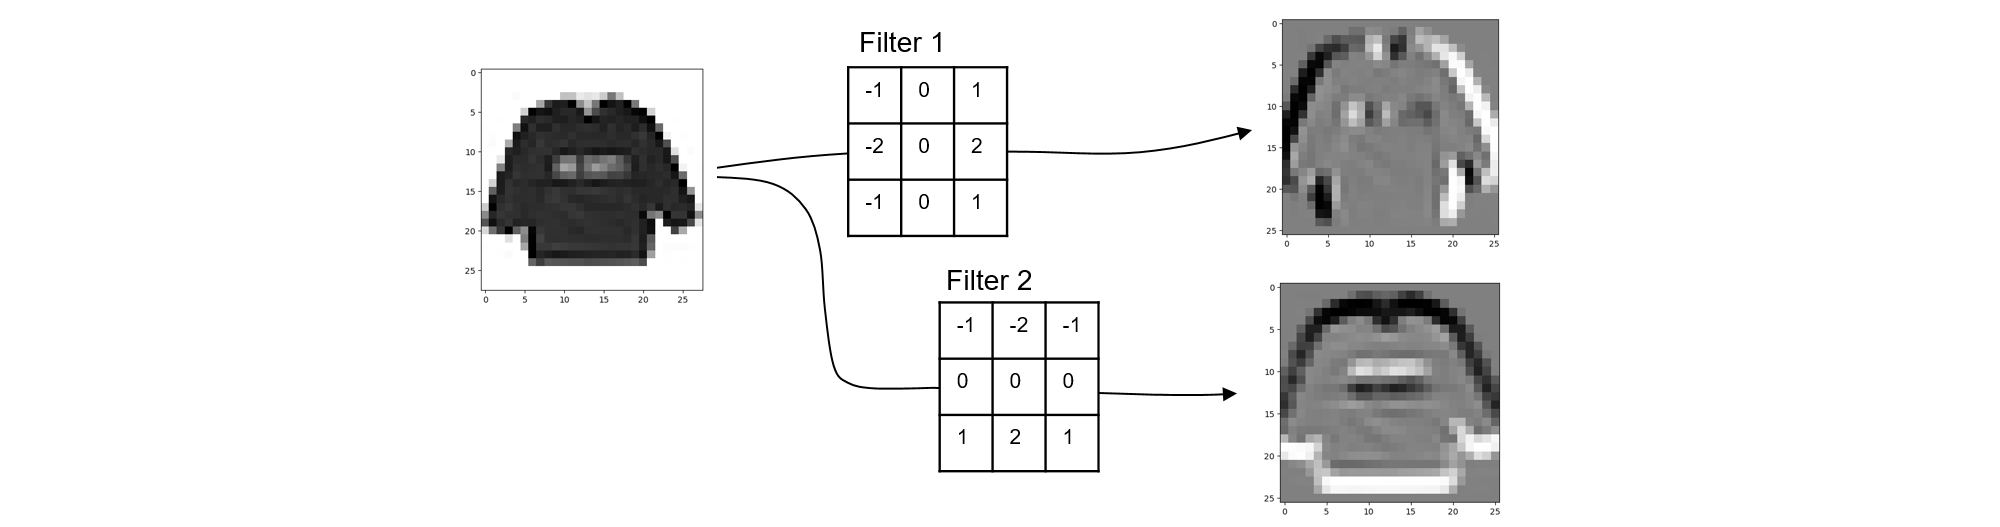

### Prepare a handcrafted Kernel

In [ ]:
#horizontal edge detection 
sobel_y = np.array([[ -1, -2, -1], 
                    [ 0, 0, 0], 
                    [ 1, 2, 1]])
# vertical edge detection
sobel_x = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])

In [ ]:
# Define 3x3 kernel with predefined weights
weights = tf.constant(sobel_x, dtype=tf.float32)

# Expand kernel to 4D shape for compatibility with input tensor 
kernel = tf.reshape(weights, [3, 3, 1, 1]) # dim1, dim2, inputchannels, kernels
kernel

### Make a One Layer Model

In [ ]:
model = Sequential()
model.add(InputLayer((28, 28, 1)))
conv = Conv2D(1,
              kernel_size=(3,3),    # we neglect the input channels aka color channels
              activation="sigmoid")  
model.add(conv)
conv.set_weights([kernel, tf.zeros([1])]);
model.summary()

In [ ]:
rescaledImage = X_train[0]/255  # has to be rescaled because of the sigmoid
result = model.predict(rescaledImage.reshape(1, 28,28,1)) # nr of samples, x, y, color channels
print(result.shape)
img = result[0] 
plt.imshow(img, cmap='binary')

Explain why we have gray background where we first started with white background (= 0 = no color) ?

In [ ]:
img.reshape(-1)

In [ ]:
# shift and take absolte values
plt.imshow(np.abs(img-0.5), cmap='binary')

In [ ]:
# for comparison the original image
plt.imshow(X_train[0].reshape(28,28)/255,cmap='binary')
plt.show()

## Applying the filter to a larger image 

In [ ]:
from PIL import Image
import numpy as np

# Load the image
img = Image.open('oldtimer.jpg')
# Convert to grayscale
gray_img = img.convert('L')

# Resize the image
resized_img = gray_img.resize((224, 224))

# Normalize the image to rang 0 to 1
normalized_img = np.array(resized_img) / 255.0

plt.imshow(normalized_img, 'gray')

In [ ]:
result = model.predict(normalized_img.reshape(1, 224,224,1))
plt.imshow(np.abs(result.reshape(222,222)-0.5), 'binary')

## Conv2D Layer can have multiple Kernels

In [ ]:
# We have two kernels in variables sobel_x, sobel_y in the format (x-dim, ydim)
print("Filter one shape: ", sobel_x.shape)
print("Filter two shape: ", sobel_y.shape)

# How to bring then into a (x-dim, ydim, channels, kernels) ? 
#                          (3    , 3,     1,        2)
intermediate = list(zip(sobel_x.reshape(-1), sobel_y.reshape(-1)))
np.array(intermediate).reshape(3,3,1,2)


In [ ]:
# We convert the two kernels in sobel_x, sobel_y to the format (x-dim, ydim, channels, kernels)
zipped = list(zip(sobel_x.reshape(-1), sobel_y.reshape(-1)))
kernels = tf.reshape(tf.constant(zipped, dtype=tf.float32), [3, 3, 1, 2])

model = Sequential()
model.add(InputLayer((28, 28, 1)))
conv = Conv2D(2, 
              kernel_size=(3,3),
              activation="sigmoid")
model.add(conv)
conv.set_weights([kernels, tf.zeros([2])]);
print(f"Kernel Dimensions: {kernels.shape}")
model.summary()

In [ ]:
rescaledImage = X_train[0]/255
result = model.predict(rescaledImage.reshape(1, 28,28,1))
print(result.shape)
#1 26 26 2

In [ ]:
result[0,:,:,0].shape

In [ ]:
fig, (ax1,ax2) = plt.subplots(1,2)
ax1.imshow(result[0,:,:,0], cmap='binary')
ax2.imshow(result[0,:,:,1], cmap='binary')